In [1]:
import networkx as nx
import torch
import json
from pathlib import Path
from torch.utils.data import Subset
from torch_geometric.utils.convert import from_networkx
from torch_geometric.data import Data

/Users/fangjun/Documents/stanford/cs224w/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Visualize a Pipeline DAG

In [2]:
# Load the pipeline DAG from a JSON file.
DAG_JSON_PATH = "../pipelines/pipeline_0/dag.json"
with open(DAG_JSON_PATH, "r") as f:
    dag_data = json.load(f)

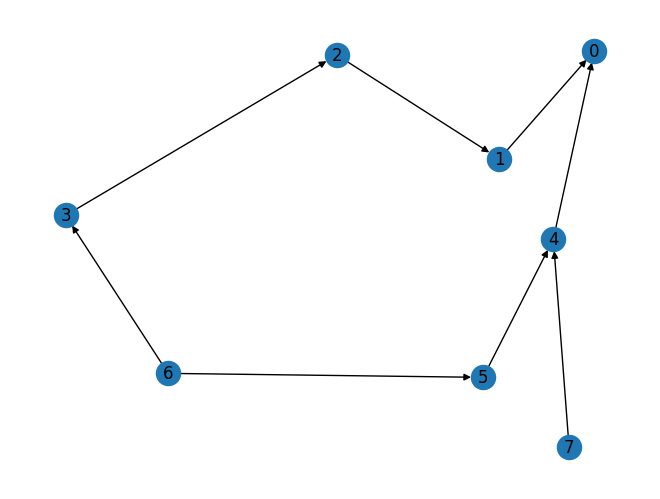

In [3]:
func_names = [func["name"] for func in dag_data]
dag = nx.DiGraph()
# Add function nodes.
for idx, func_name in enumerate(func_names):
    dag.add_node(idx, name={func_name})
# Add edges based on dependencies.
for idx, func in enumerate(dag_data):
    for dep in func["parents"]:
        dep_idx = func_names.index(dep)
        dag.add_edge(dep_idx, idx)
# Visualize the DAG.
nx.draw(dag, with_labels=True)

In [4]:
# Pipeline Benchmark Result
BENCHMARK_PATH = "../pipelines/pipeline_0/benchmark.json"
with open(BENCHMARK_PATH, "r") as f:
    benchmark_data = json.load(f)
y = torch.tensor([benchmark["real_time"] for benchmark in benchmark_data["benchmarks"]], dtype=torch.float)
y

tensor([   3.0854,   12.6092,   52.6497,  217.8877, 1023.1951])

In [5]:
x = torch.ones((len(dag.nodes), 1), dtype=torch.float)
edge_index = torch.tensor(list(dag.edges)).T
pyg_dag = Data(x=x, edge_index=edge_index, y=y)
pyg_dag

Data(x=[8, 1], edge_index=[2, 8], y=[5])

# Use Data Utils to Load Dataset

In [6]:
from halide_gnn_cost_model.data import load_pipeline, PipelineDataset

In [7]:
data = load_pipeline(Path("../pipelines/pipeline_0"))
data

HeteroData(
  y=[5],
  function={ x=[8, 1] },
  (function, called_by, function)={ edge_index=[2, 8] }
)

In [8]:
dataset = PipelineDataset(Path("../pipelines"))
len(dataset)

32

In [9]:
for idx, data in enumerate(Subset(dataset, range(8))):
    print(f"Pipeline {idx} has {data['function'].x.shape[0]} functions.")

Pipeline 0 has 5 functions.
Pipeline 1 has 8 functions.
Pipeline 2 has 12 functions.
Pipeline 3 has 7 functions.
Pipeline 4 has 3 functions.
Pipeline 5 has 5 functions.
Pipeline 6 has 7 functions.
Pipeline 7 has 6 functions.
